<a href="https://colab.research.google.com/github/VaibhavRajput022/Codsoft/blob/main/IRIS_FLOWER_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification: A Machine Learning Project for Codsoft Internship


In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target # Target (species: 0, 1, 2)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 3. Choose and train a classification model (Logistic Regression is a good starting point)
model = LogisticRegression(max_iter=200, solver='liblinear') # Increase max_iter for convergence, use liblinear for smaller datasets
model.fit(X_train, y_train)

# 4. Evaluate the model's performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel trained successfully!")
print(f"Accuracy of the Logistic Regression model: {accuracy:.2f}")

# You can also see the species names
print(f"\nIris species names: {iris.target_names}")


Training data shape: (105, 4)
Testing data shape: (45, 4)

Model trained successfully!
Accuracy of the Logistic Regression model: 0.98

Iris species names: ['setosa' 'versicolor' 'virginica']


## Data Exploration and Visualization

Before training the model, let's visualize the Iris dataset to understand the distribution of features and how different species are separated. This helps in gaining insights into the data characteristics.

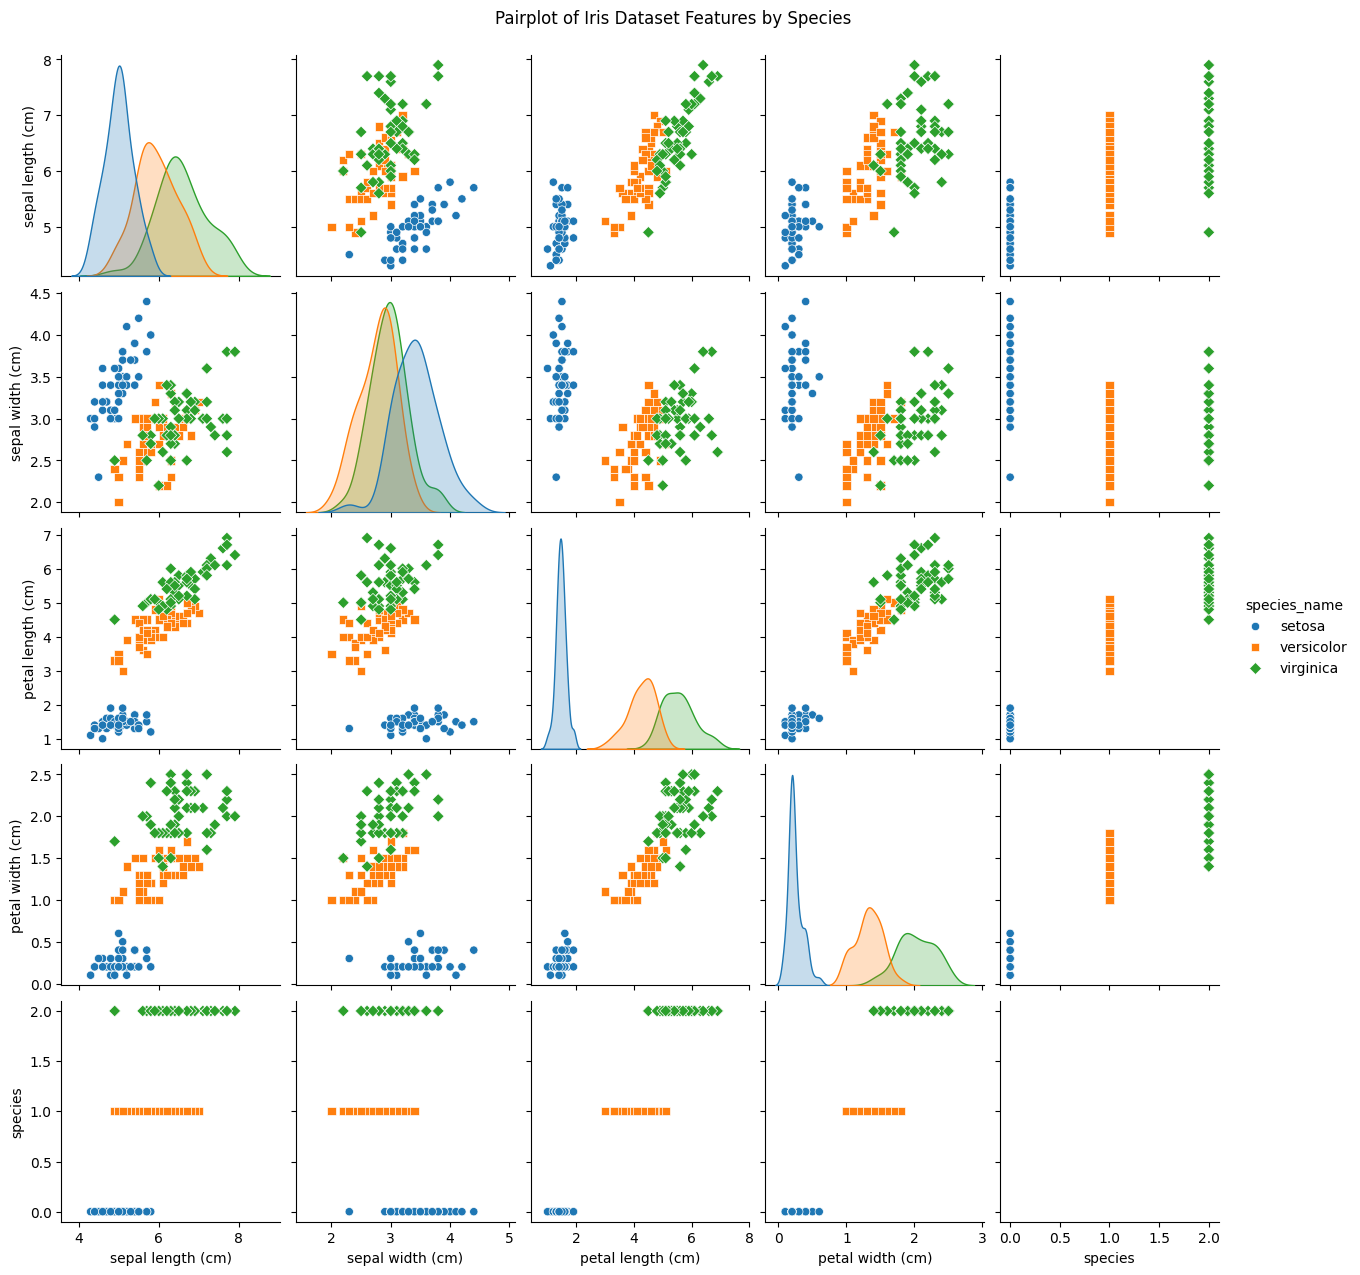

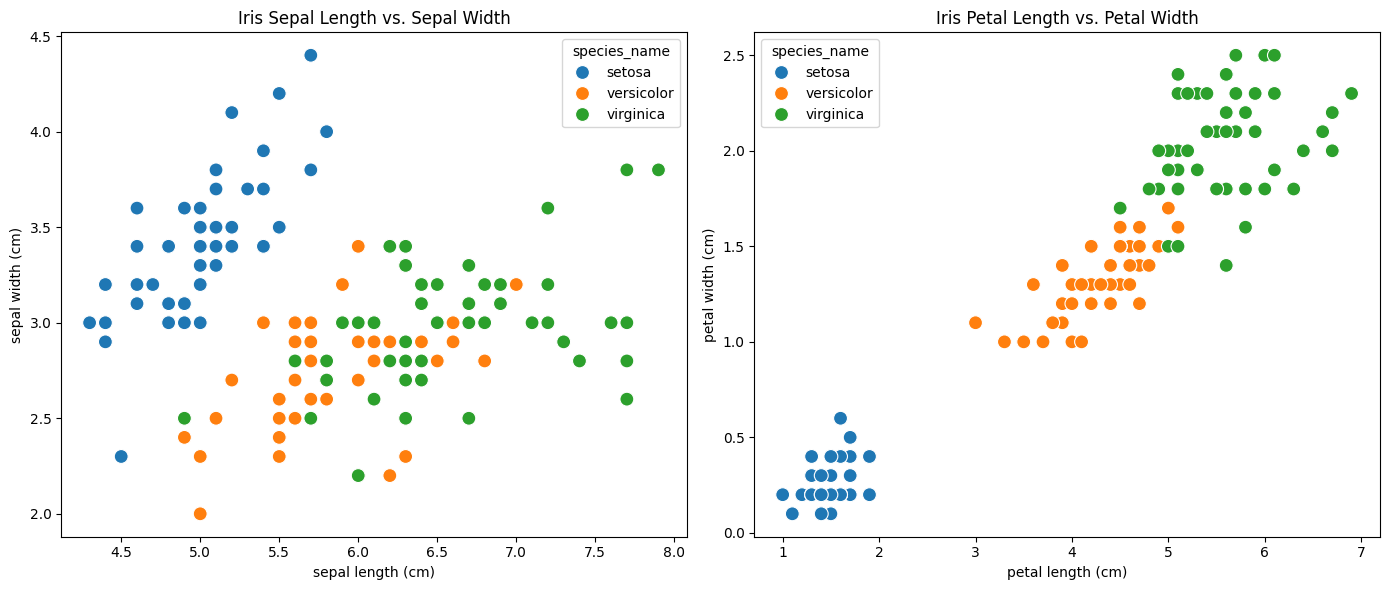

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting with Seaborn
import pandas as pd
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species_name'] = iris.target_names[iris.target]

# Pairplot to visualize relationships between all features
sns.pairplot(iris_df, hue='species_name', markers=['o', 's', 'D'])
plt.suptitle('Pairplot of Iris Dataset Features by Species', y=1.02) # Add a title to the pairplot
plt.show()

# Let's also visualize a specific pair: sepal length vs sepal width
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species_name', data=iris_df, ax=ax[0], s=100)
ax[0].set_title('Iris Sepal Length vs. Sepal Width')

# Petal length vs petal width
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species_name', data=iris_df, ax=ax[1], s=100)
ax[1].set_title('Iris Petal Length vs. Petal Width')

plt.tight_layout()
plt.show()

From the visualizations, especially the petal length and petal width plots, it's clear that the 'setosa' species is linearly separable from the other two. 'versicolor' and 'virginica' show some overlap but are largely separable, suggesting that a linear model like Logistic Regression can perform well.